# 进阶案例：预置场景、共享链路、云区域延迟

## 1. 使用预置设备构造异构边缘集群

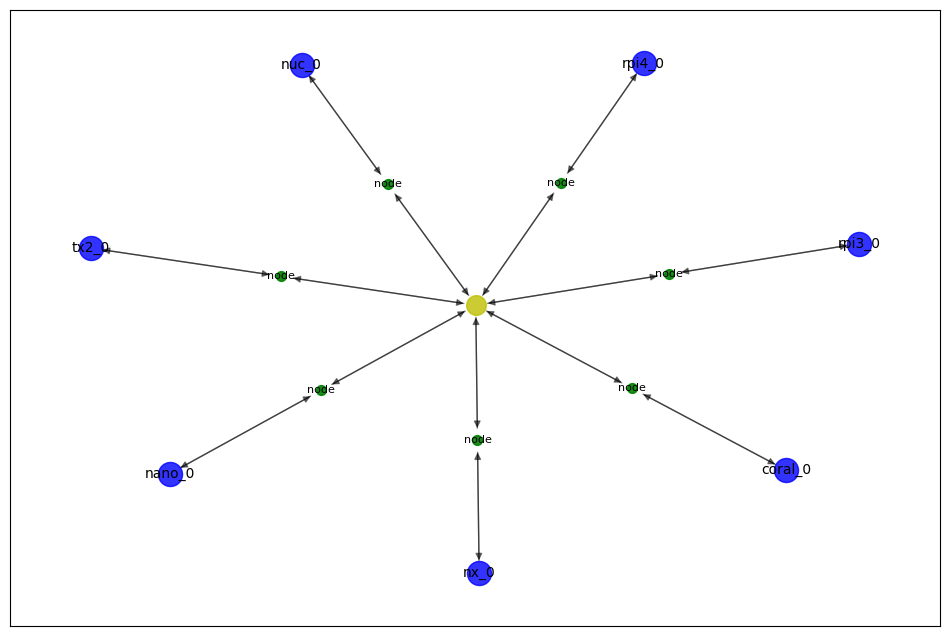

In [1]:
from ether.cell import LANCell
from ether.blocks import nodes

edge_cluster = LANCell([
    nodes.rpi3,
    nodes.rpi4,
    nodes.nuc,
    nodes.tx2,
    nodes.nano,
    nodes.nx,
    nodes.coral
])

topology = edge_cluster.generate()

import matplotlib.pyplot as plt
from ether.vis import draw_basic

fig, ax = plt.subplots(figsize=(12, 8))
draw_basic(topology)
plt.show()


这个例子会创建一个异构边缘集群。不同节点有不同：

- CPU 架构。
- CPU/内存容量。
- 设备类型标签。
- GPU/TPU 能力标签。

这类拓扑适合测试调度器能否正确处理异构硬件。

## 2. 创建边缘 Cloudlet

10
12


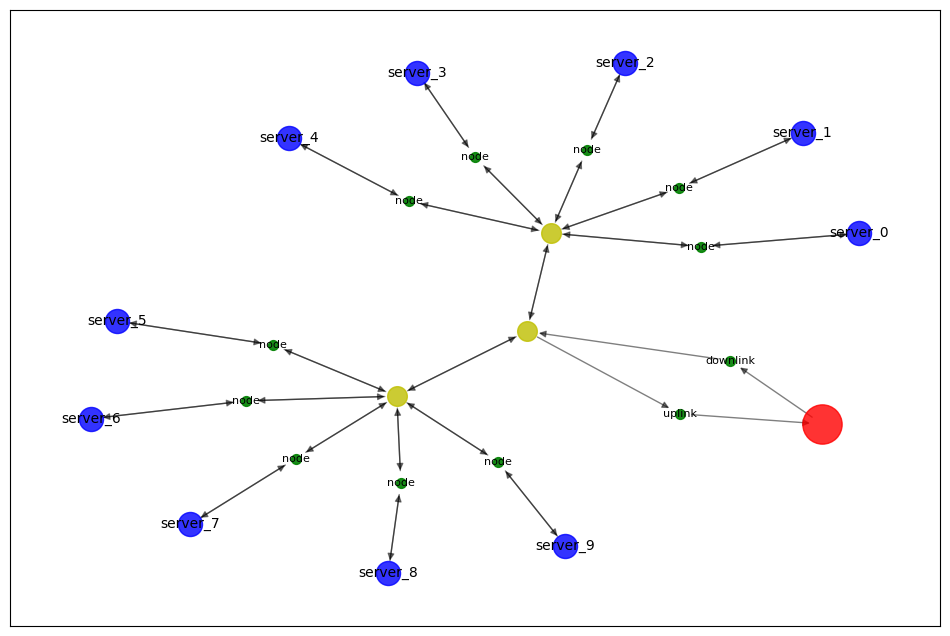

In [2]:
from ether.blocks.cells import Cloudlet, FiberToExchange

cloudlet = Cloudlet(
    server_per_rack=5,
    racks=2,
    backhaul=FiberToExchange("internet")
)

topology = cloudlet.generate()

print(len(topology.get_nodes()))
print(len(topology.get_links()))

import matplotlib.pyplot as plt
from ether.vis import draw_basic
fig, ax = plt.subplots(figsize=(12, 8))
draw_basic(topology)
plt.show()

`Cloudlet(5, 2)` 会生成两个机架，每个机架 5 台 server，总共 10 台服务器。

## 3. 移动网络回传

3
6


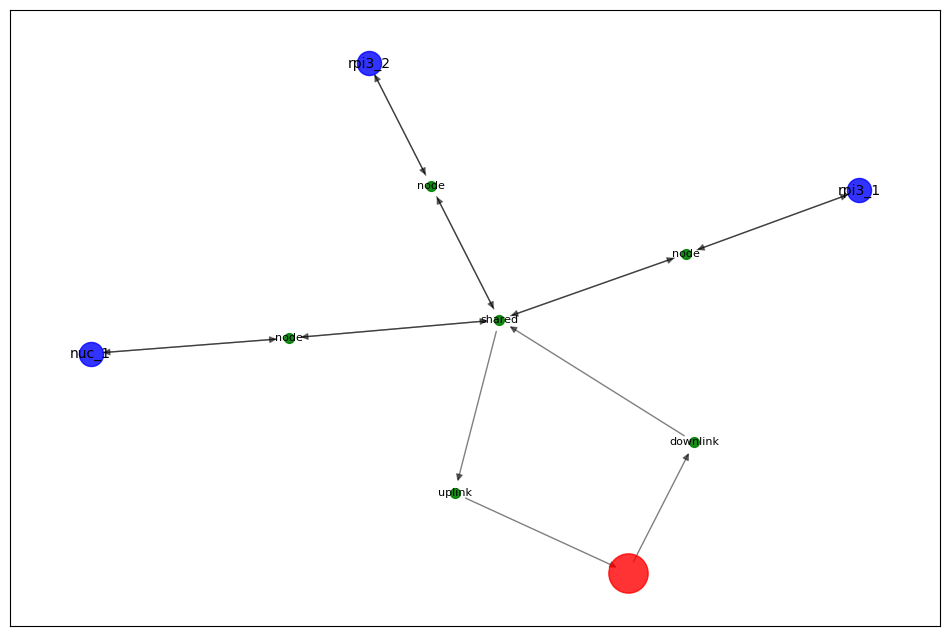

In [3]:
from ether.cell import SharedLinkCell
from ether.blocks import nodes
from ether.blocks.cells import MobileConnection

mobile_edge = SharedLinkCell(
    nodes=[nodes.rpi3, nodes.rpi3, nodes.nuc],
    shared_bandwidth=125,
    backhaul=MobileConnection("internet")
)

topology = mobile_edge.generate()

print(len(topology.get_nodes()))
print(len(topology.get_links()))

import matplotlib.pyplot as plt
from ether.vis import draw_basic

fig, ax = plt.subplots(figsize=(12, 8))
draw_basic(topology)
plt.show()


`MobileConnection` 使用上下行非对称带宽，适合模拟移动网络场景。

## 4. 城市感知场景

nodes: 41
links: 52


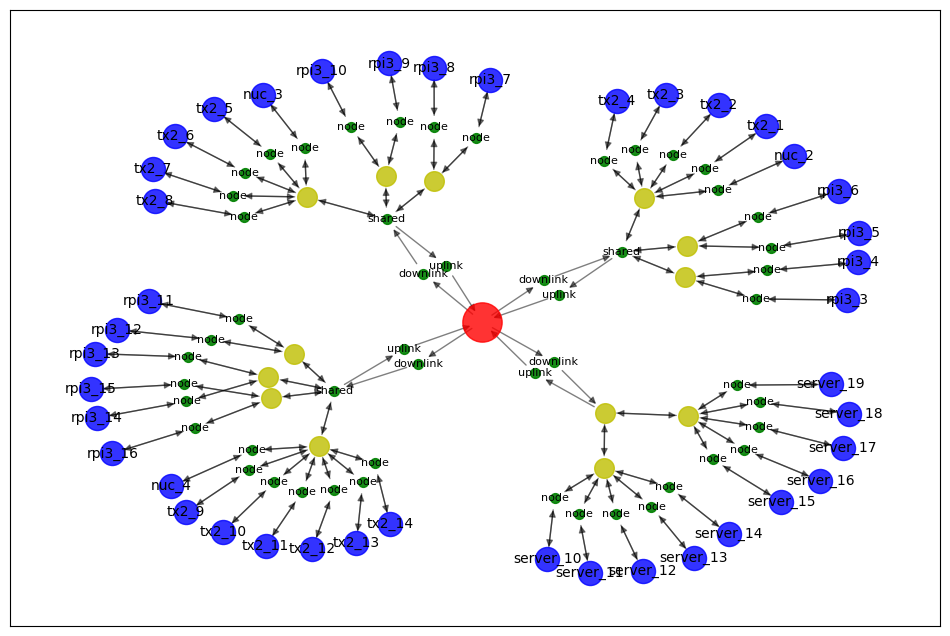

In [4]:
from ether.topology import Topology
from ether.scenarios.urbansensing import UrbanSensingScenario

topology = Topology()
scenario = UrbanSensingScenario(
    num_cells=3,
    cloudlet_size=(5, 2),
    internet="internet"
)

topology.add(scenario)

print("nodes:", len(topology.get_nodes()))
print("links:", len(topology.get_links()))

import matplotlib.pyplot as plt
from ether.vis import draw_basic

fig, ax = plt.subplots(figsize=(12, 8))
draw_basic(topology)
plt.show()


城市感知场景包含：

- 多个地理小区。
- 传感器节点。
- 近端计算盒。
- 移动回传。
- 城市级 Cloudlet。

这个场景适合测试：

- 边缘计算部署。
- 网络瓶颈。
- 异构节点调度。
- 云边协同。

## 5. 工业物联网场景


nodes: 20
links: 25


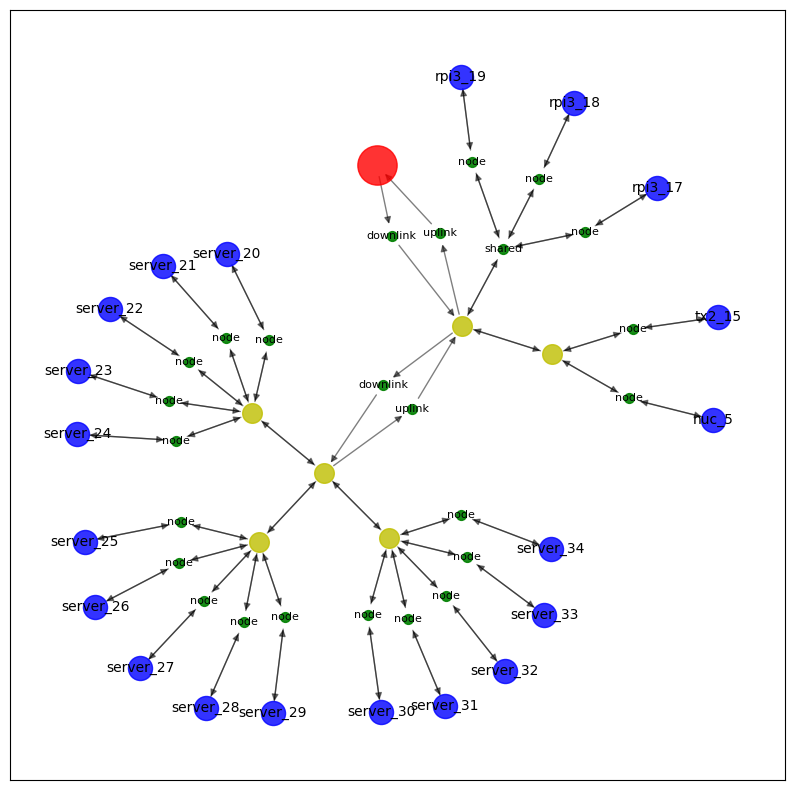

In [5]:
from ether.topology import Topology
from ether.scenarios.industrialiot import IndustrialIoTScenario

topology = Topology()
topology.add(IndustrialIoTScenario())

print("nodes:", len(topology.get_nodes()))
print("links:", len(topology.get_links()))

import matplotlib.pyplot as plt
from ether.vis import draw_basic

plt.figure(figsize=(10, 10))
draw_basic(topology)
plt.show()


工业物联网场景通常用于模拟工厂、企业网络、现场设备和边缘计算资源。

## 6. 云区域场景

nodes: 30
links: 30


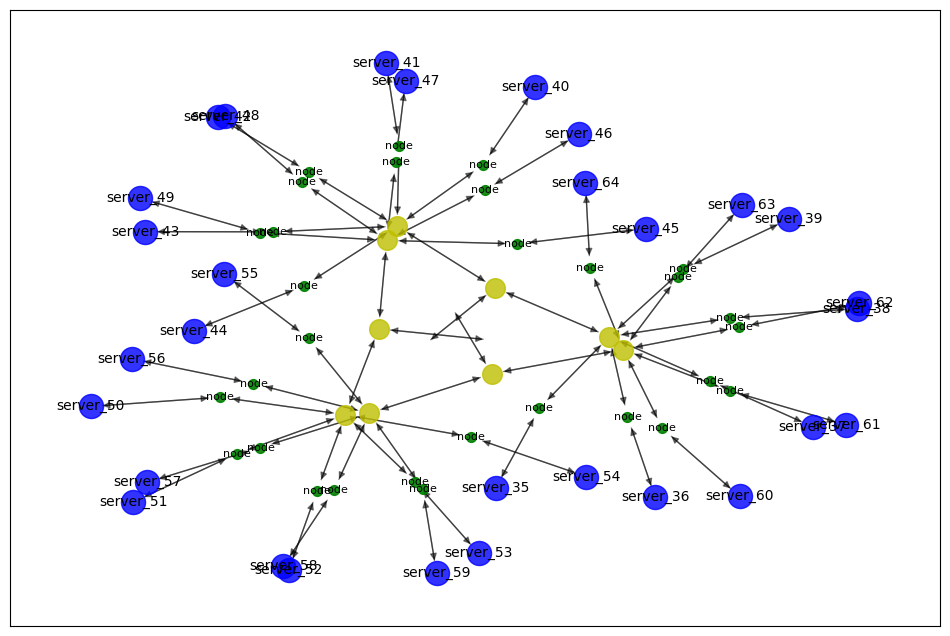

In [6]:
from ether.topology import Topology
from ether.scenarios.cloudregions import CloudRegionsScenario

topology = Topology()
topology.add(CloudRegionsScenario(
    regions=["us-east-1", "eu-west-1", "ap-southeast-1"],
    region_size= [(5, 2), (5, 2), (5, 2)]
))

print("nodes:", len(topology.get_nodes()))
print("links:", len(topology.get_links()))

import matplotlib.pyplot as plt
from ether.vis import draw_basic

fig, ax = plt.subplots(figsize=(12, 8))
draw_basic(topology)
plt.show()

云区域场景适合模拟跨云区域 RTT。

## 7. 加载互联网延迟图

`Topology.load_inet_graph(source)` 可以把预置的互联网区域延迟图加载进拓扑。

In [7]:
from ether.topology import Topology

topology = Topology()
topology.load_inet_graph("cloudping")

loading from D:\研\7毕设\2 大论文\修辅\07-06\faas-sim-master\ether\inet\graphs\cloudping_latest.graphml


项目中已有 graphml 数据，例如：

- `ether/inet/graphs/cloudping_latest.graphml`
- `ether/inet/graphs/gcloudping_latest.graphml`
- `ether/inet/graphs/wondernetwork_latest.graphml`


## 8. 共享链路下的公平性验证

如果多个 Flow 同时经过同一条瓶颈链路，理想情况下它们会接近公平共享。

假设 bottleneck 是 10 Mbit/s：

- 单个流接近 10 Mbit/s。
- 两个流接近 5 Mbit/s。
- 三个流接近 3.33 Mbit/s。

Ether 中还会乘以 TCP goodput 近似系数，所以最终吞吐略低于理论带宽。

## 9. 如何检查拓扑是否符合预期

常用检查：

```python
print(topology.get_nodes())
print(topology.get_links())

route = topology.route(source, destination)
print(route.path)
print(route.hops)
print(route.rtt)
```

如果 `route.hops` 为空，说明路径没有经过 `Link`，网络流无法计算带宽。

## 10. 如何选择建模方式

| 需求 | 推荐 |
|---|---|
| 自己完全控制结构 | 手工 `Node`、`Link`、`Connection` |
| 小型局域网 | `LANCell` |
| 多设备共享出口 | `SharedLinkCell` |
| 上下行不对称 | `UpDownLink` 或 `MobileConnection` |
| 异构边缘设备 | `blocks.nodes` |
| 城市级拓扑 | `UrbanSensingScenario` |
| 工业场景 | `IndustrialIoTScenario` |
| 云区域 RTT | `CloudRegionsScenario`、`inet` |